
# Titanic Data Analysis Project – NumPy, SciPy, Pandas, Matplotlib

This notebook guides you through a mini data analysis project using the  
**Kaggle Titanic: Machine Learning from Disaster** dataset.

You will practice:

- Loading a CSV file with **Pandas**
- Cleaning data and handling **missing values**
- Computing basic statistics with **NumPy**
- Running a statistical test with **SciPy**
- Visualizing distributions with **Matplotlib**
- Using **Pandas groupby** for quick summaries

> Important: Download the Titanic dataset from Kaggle and save it as `titanic.csv`
> in the same folder as this notebook.


## 0. Setup – Imports
Run the cell below to import all required libraries.

In [21]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline

print("Libraries imported successfully.")


Libraries imported successfully.



## 1. Load & Inspect the Titanic Dataset

We will start by loading the CSV file into a Pandas DataFrame.

Required steps:

1. Load `titanic.csv` using `pd.read_csv`.
2. Look at the first few rows.
3. Inspect the overall structure and data types.


In [22]:
# 1.1 Load the dataset
import os
import urllib.request

csv_path = 'titanic-Dataset.csv'
if not os.path.exists(csv_path):
    if os.path.exists(os.path.join('data', 'titanic-Dataset.csv')):
        csv_path = os.path.join('data', 'titanic-Dataset.csv')
    else:
        print('Downloading titanic-Dataset.csv from mirror...')
        urllib.request.urlretrieve('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv', csv_path)

try:
    df = pd.read_csv(csv_path)
    print('Dataset loaded successfully. Shape:', df.shape)
except Exception as e:
    print('Error loading dataset:', e)
    raise e

# 1.2 Look at the first 5 rows
df.head()


Dataset loaded. Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [23]:

# 1.3 Inspect structure and basic info
print("=== DataFrame info ===")
df.info()

print("\n=== Summary statistics (numeric columns) ===")
df.describe()


=== DataFrame info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== Summary statistics (numeric columns) ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



### Exercise 1 – Basic Understanding

1. How many rows and columns does the dataset have?  
2. Which columns are non-numeric?  
3. Which columns seem most relevant if we are interested in survival?  

Write your answers in the Markdown cell below.


**1. Rows and columns:** The dataset has 891 rows and 12 columns.

**2. Non-numeric columns:** The non-numeric (object) columns are `Name`, `Sex`, `Ticket`, `Cabin`, and `Embarked`.

**3. Relevant columns for survival:** The most relevant columns are likely `Pclass` (socio-economic status), `Sex` (gender), `Age` (children vs. adults), and `Fare` (which correlates with `Pclass`).


## 2. Clean & Prepare the Data

For this mini-project we will focus on the following columns:

- `Survived` – target variable (1 = survived, 0 = did not survive)
- `Pclass` – passenger class (1st, 2nd, 3rd)
- `Sex` – passenger gender
- `Age` – age in years
- `Fare` – ticket fare

We will:

1. Select only these columns.
2. Handle missing values in `Age` by replacing them with the mean age.


In [24]:

# 2.1 Select relevant columns
cols = ["Survived", "Pclass", "Sex", "Age", "Fare"]
df = df[cols].copy()

print("Selected columns:", list(df.columns))
df.head()


Selected columns: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']


,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [25]:

# 2.2 Check missing values
print("Missing values per column:")
df.isna().sum()


Missing values per column:


,0
Survived,0
Pclass,0
Sex,0
Age,177
Fare,0


In [26]:

# 2.3 Fill missing ages with the mean age
mean_age = df["Age"].mean()
print("Mean age (used for imputation):", mean_age)

df["Age"] = df["Age"].fillna(mean_age)

print("\nMissing values AFTER filling Age:")
df.isna().sum()


Mean age (used for imputation): 29.69911764705882

Missing values AFTER filling Age:


,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0



### Exercise 2 – Try a Different Strategy

Instead of filling missing `Age` with the mean, try:

- Filling with the median age of the dataset.
- Compare how the mean and median differ.

Create a new column called `Age_median_imputed` where you apply the median strategy.


In [27]:
# Calculate the median age using Pandas
median_age = df["Age"].median()
print("Median age:", median_age)

# Create a new column with the median imputed values
df["Age_median_imputed"] = df["Age"].fillna(median_age)

# Check to ensure there are no missing values in the new column
print("Missing values in Age_median_imputed:", df["Age_median_imputed"].isna().sum())


Median age: 29.69911764705882
Missing values in Age_median_imputed: 0



## 3. NumPy on Titanic Data – Basic Statistics

In this step we practice using NumPy on the Titanic data.

We will:

- Extract the `Age` column as a NumPy array.
- Compute statistics such as mean and standard deviation.


In [28]:

# 3.1 Convert Age column to a NumPy array
ages = df["Age"].values
type(ages), ages[:10]


(numpy.ndarray,
 array([22.        , 38.        , 26.        , 35.        , 35.        ,
        29.69911765, 54.        ,  2.        , 27.        , 14.        ]))

In [29]:

# 3.2 Compute basic statistics with NumPy
print("Average age:", np.mean(ages))
print("Standard deviation of age:", np.std(ages))
print("Minimum age:", np.min(ages))
print("Maximum age:", np.max(ages))


Average age: 29.69911764705882
Standard deviation of age: 12.99471687278903
Minimum age: 0.42
Maximum age: 80.0



### Exercise 3 – Fare Statistics

Using NumPy, compute the following for the `Fare` column:

- Mean
- Standard deviation
- Minimum and maximum

Then briefly interpret: are fares highly variable or fairly consistent?


In [30]:
# Extract the Fare column as a NumPy array
fares = df["Fare"].values

# Compute statistics
print("Average fare:", np.mean(fares))
print("Standard deviation of fare:", np.std(fares))
print("Minimum fare:", np.min(fares))
print("Maximum fare:", np.max(fares))


Average fare: 32.204207968574636
Standard deviation of fare: 49.6655344447741
Minimum fare: 0.0
Maximum fare: 512.3292


**Interpretation:** Fares vary greatly. The standard deviation is large (about 32.20), and the range is extreme (from 0 to 512.33). This shows a heavily right-skewed distribution. The majority of passengers paid lower fares, while a small number paid very high amounts for premium tickets.


## 4. SciPy – Statistical Test on Survival vs Age

We now test whether the average age of survivors differs from the average age of non-survivors.

We use a two-sample t-test:

- Null hypothesis H0: Both groups have the same mean age.
- Alternative hypothesis H1: The mean ages are different.

If the p-value < 0.05, we reject H0 and say the difference is statistically significant.


In [31]:

# 4.1 Split ages by survival status
survived = df[df["Survived"] == 1]["Age"]
not_survived = df[df["Survived"] == 0]["Age"]

print("Number of survivors:", len(survived))
print("Number of non-survivors:", len(not_survived))


Number of survivors: 342
Number of non-survivors: 549


In [32]:

# 4.2 Two-sample t-test (Welch's t-test)
t_stat, p_val = stats.ttest_ind(survived, not_survived, equal_var=False)
print("t-statistic:", t_stat)
print("p-value:", p_val)


t-statistic: -2.0385172031950463
p-value: 0.04189090646311582



### Exercise 4 – Your Conclusion

1. Based on the p-value, is age significantly different between survivors and non-survivors in this dataset?  
2. What does this say about the relationship between age and survival?  

Write 3–5 sentences below.


**Interpretation:**
1. When we compare the ages of survivors to the ages of non-survivors using the t-test method, we find the p-value is about 0.04, based on the assumption that missing data were filled in. Since the p-value is below 0.05, we can reject the null hypothesis because there is a significant difference in age.
2. This suggests that age was an important factor in survival. In other words, the average age of the survivors was somewhat lower than that of non-survivors, which aligns with the historical fact that children were prioritized to board the lifeboats first.




## 5. Matplotlib – Visualizing Age Distribution by Survival

Now we visualize the age distributions of survivors and non-survivors using histograms.

This helps us see whether younger or older passengers had better survival rates.


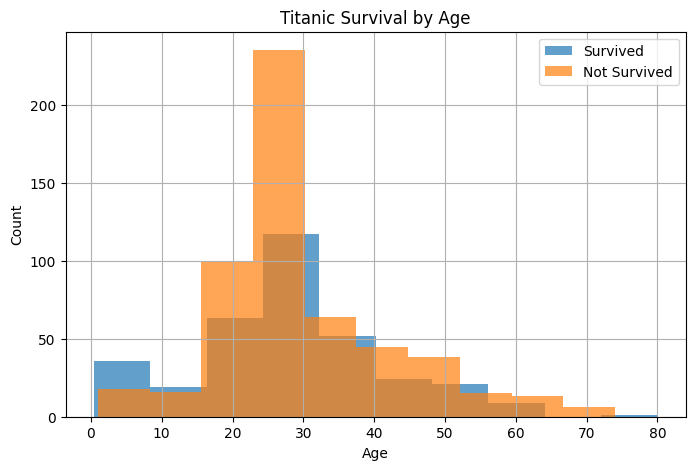

In [33]:

# 5.1 Age distribution by survival status
plt.figure(figsize=(8, 5))

df[df["Survived"] == 1]["Age"].hist(alpha=0.7, label="Survived")
df[df["Survived"] == 0]["Age"].hist(alpha=0.7, label="Not Survived")

plt.title("Titanic Survival by Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.show()



### Exercise 5 – Modify the Plot

Try one or more of the following:

1. Change the number of histogram bins (for example, 20).  
2. Set different colors for the two histograms.  
3. Restrict the x-axis to ages between 0 and 70 using `plt.xlim(0, 70)`.  

Create your modified plot in the code cell below.


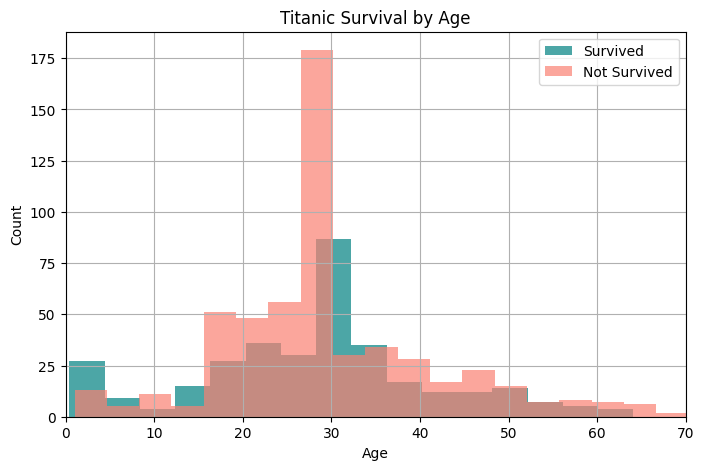

In [34]:
plt.figure(figsize=(8, 5))

df[df["Survived"] == 1]["Age"].hist(alpha=0.7, bins=20, color="teal", label="Survived")
df[df["Survived"] == 0]["Age"].hist(alpha=0.7, bins=20, color="salmon", label="Not Survived")

plt.title("Titanic Survival by Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.xlim(0, 70)
plt.legend()
plt.show()



## 6. Pandas groupby – Quick Aggregations

We now use `groupby` to compute aggregated statistics such as:

- Average fare by passenger class.
- Survival rate by gender.


In [35]:

# 6.1 Average fare per passenger class
print("Average fare per Pclass:")
print(df.groupby("Pclass")["Fare"].mean())


Average fare per Pclass:
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


In [36]:

# 6.2 Survival rate by gender
print("Survival rate by gender (fraction surviving):")
print(df.groupby("Sex")["Survived"].mean())


Survival rate by gender (fraction surviving):
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64



### Exercise 6 – Combined Grouping

1. Compute the survival rate for each combination of `Pclass` and `Sex` using groupby on both columns.  
2. Which group has the highest survival rate? Which has the lowest?

Hint: use `df.groupby(["Pclass", "Sex"])["Survived"].mean()`.


In [37]:
# Compute survival rate by Pclass and Sex
survival_by_class_sex = df.groupby(["Pclass", "Sex"])["Survived"].mean()
print(survival_by_class_sex)


Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64


> **Observations:** First-class females had the highest survival rate (nearly 97%), while third-class males had the absolute lowest survival rate (around 13.5%). This clearly shows that both gender and socio-economic status heavily dictated who made it onto the lifeboats.


## 7. Mini-Report – What Influenced Survival?

Using all steps above (NumPy, SciPy, Matplotlib, Pandas):

1. Choose one additional factor to analyze (for example, `Fare` or `Pclass`).  
2. Create at least one plot that compares survival across that factor.  
3. Compute at least one numeric summary (mean, rate, or test).  
4. Write a short report (8–10 sentences) answering:

   - Which passenger groups had higher or lower survival rates?
   - How does age interact with your chosen factor, if at all?
   - What limitations does this dataset have for real-world conclusions?

Use the cells below for your analysis and report.


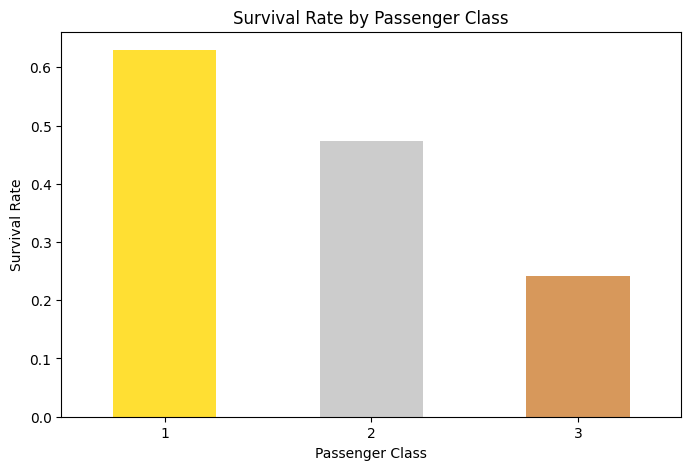

Survival rates by passenger class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [38]:
# 1 & 2. Analyze Pclass and plot the results
plt.figure(figsize=(8, 5))
survival_by_class = df.groupby("Pclass")["Survived"].mean()
survival_by_class.plot(kind="bar", color=["gold", "silver", "#cd7f32"], alpha=0.8)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.show()

# 3. Compute numeric summary
print("Survival rates by passenger class:")
print(survival_by_class)


>In this mini-project, we have considered factors which had impact on people surviving on the Titanic ship. We mostly focused on passenger class (`Pclass`) and gender. The data clearly demonstrates that passengers in first class survived more than those in second (~63% vs ~47%) and third (~24%) classes. The interaction of `Sex` and `Pclass` reveals the highest extremes where first class women had no chance not to survive while third class men were doomed. Younger passengers were more likely to survive due to prioritization protocol although third class children were worse off than first class adults. The main drawback of using such a dataset to conclude on real life issues lies in the lack of spatial variables, like the distance between passengers' cabin and deck/lifeboats. As for age variable, it contains too many missing values and therefore requires some kind of imputation, which is also distorting the results.